Using device: cuda
Epoch [1/20], Loss: 0.1713
Epoch [2/20], Loss: 0.1314
Epoch [3/20], Loss: 0.1208
Epoch [4/20], Loss: 0.1137
Epoch [5/20], Loss: 0.1051
Epoch [6/20], Loss: 0.0926
Epoch [7/20], Loss: 0.1060
Epoch [8/20], Loss: 0.1040
Epoch [9/20], Loss: 0.0902
Epoch [10/20], Loss: 0.0962
Epoch [11/20], Loss: 0.0861
Epoch [12/20], Loss: 0.0869
Epoch [13/20], Loss: 0.0879
Epoch [14/20], Loss: 0.0991
Epoch [15/20], Loss: 0.0856
Epoch [16/20], Loss: 0.0902
Epoch [17/20], Loss: 0.0896
Epoch [18/20], Loss: 0.0852
Epoch [19/20], Loss: 0.0826
Epoch [20/20], Loss: 0.0872
Validation Accuracy: 98.38%


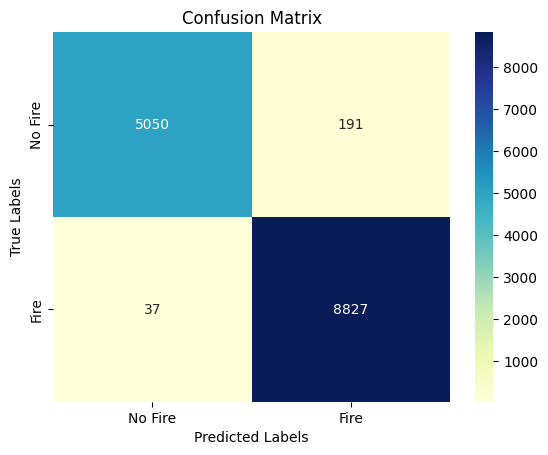

In [13]:
# 2. Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import pandas as pd
import os
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Set Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 4. Custom Dataset Class
class WildfireDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Drop rows with NaN values in the 'fire' column
        self.annotations = self.annotations.dropna(subset=['fire'])

        # Optionally, ensure that labels are valid (0 or 1)
        self.annotations = self.annotations[self.annotations['fire'].isin([0, 1])]

        # Shuffle the data
        self.annotations = self.annotations.sample(frac=1, random_state=42).reset_index(drop=True)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_name = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_name).convert("RGB")

        # Handle potential NaN or invalid label values
        label = int(self.annotations.iloc[index, 1]) if pd.notna(self.annotations.iloc[index, 1]) else 0

        if self.transform:
            image = self.transform(image)

        return image, label

# 5. Define Data Transforms with Data Augmentation for Training Set
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),   # Random horizontal flip
    transforms.RandomRotation(30),        # Random rotation up to 30 degrees
    transforms.RandomCrop(224, padding=20),  # Random cropping with padding
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Random color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Normal transforms (without augmentation) for Validation and Test sets
valid_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 6. Load Data
data_dir = r"C:\Users\user\Desktop\Forest Monitoring\wildfires_data"
classes_file = r"C:\Users\user\Desktop\Forest Monitoring\wildfires_data\wildfires_classes.csv"

dataset = WildfireDataset(csv_file=classes_file, root_dir=data_dir, transform=valid_test_transform)

# 7. Shuffle and Split the Data into Train, Validation, and Test Sets
# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)

total_size = len(dataset)
train_size = int(0.7 * total_size)
valid_size = int(0.15 * total_size)
test_size = total_size - train_size - valid_size

# Shuffle and split the dataset
train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_size, valid_size, test_size])

# Apply the train transformation only to the training set
train_dataset = WildfireDataset(csv_file=classes_file, root_dir=data_dir, transform=train_transform)
valid_dataset = WildfireDataset(csv_file=classes_file, root_dir=data_dir, transform=valid_test_transform)
test_dataset = WildfireDataset(csv_file=classes_file, root_dir=data_dir, transform=valid_test_transform)

# SMOTE to balance class distribution
train_labels = [label for _, label in train_dataset]
smote = SMOTE(random_state=seed)
data_resampled, labels_resampled = smote.fit_resample(
    np.arange(len(train_labels)).reshape(-1, 1), train_labels
)
train_indices_resampled = data_resampled.flatten()
train_dataset = torch.utils.data.Subset(train_dataset, train_indices_resampled)

# Ensure data loaders use deterministic behavior
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 8. Define the CNN Model with Dropout
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 2)
        
        # Dropout layer to prevent overfitting
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout before final layer
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

# 9. Define Weighted Loss and Optimizer with L2 Regularization (Weight Decay)
# Adding weight decay (L2 regularization) to the optimizer
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.8, 1.0]).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # weight_decay applies L2 regularization

# 10. Train the Model
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# 11. Calculate Accuracy and Performance on Test Set
def calculate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

valid_accuracy = calculate_accuracy(model, valid_loader)
print(f'Validation Accuracy: {valid_accuracy:.2f}%')

# 12. Confusion Matrix on the Test Set
def plot_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, test_loader)


In [14]:
torch.save(model.state_dict(), 'Wildfires_model.pth')